## Practical Lab: Comparative Study of KNN Classification using the Iris Dataset

### Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score
)

from sklearn.preprocessing import label_binarize

## Task 1 Dataset Understanding and Preprocessing
### Load Dataset

In [2]:
iris = load_iris()

X = iris.data
y = iris.target

df = pd.DataFrame(X, columns=iris.feature_names)
df['Species'] = y

df.head(10)

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),Species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0
5,5.4,3.9,1.7,0.4,0
6,4.6,3.4,1.4,0.3,0
7,5.0,3.4,1.5,0.2,0
8,4.4,2.9,1.4,0.2,0
9,4.9,3.1,1.5,0.1,0


### Input Features

In [3]:
print("Input Features:")
print(iris.feature_names)

print("\nTarget Classes:")
print(iris.target_names)

Input Features:
['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']

Target Classes:
['setosa' 'versicolor' 'virginica']


### Missing Values

In [4]:
print(df.isnull().sum())

sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
Species              0
dtype: int64


### Data Type

In [5]:
print(df.dtypes)

sepal length (cm)    float64
sepal width (cm)     float64
petal length (cm)    float64
petal width (cm)     float64
Species                int64
dtype: object


### Feature Scaling

In [6]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

### Train Test Split

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42
)

## The Importance of Feature Scaling in KNN

### 1. Why Feature Scaling is Necessary
The K-Nearest Neighbors (KNN) algorithm is a **distance-based classifier**. It relies entirely on geometric distance metrics (such as Euclidean or Manhattan distance) to determine the similarity between data points. 

Because of this mathematical dependency, features with naturally larger numeric ranges will dominate the distance equation. Without scaling, the algorithm will effectively ignore features with smaller numeric scales, severely compromising model accuracy.

---

### 2. The Domination Effect
Consider a dataset with two features used to classify a data point:
* **Feature A (e.g., Age):** Ranges from `10` to `80`
* **Feature B (e.g., Annual Income):** Ranges from `15,000` to `150,000`

When calculating the Euclidean distance between two samples, a difference of just $1,000 in income completely overwhelms a difference of 40 years in age. The algorithm will mistakenly treat income as the only metric that matters, even if age is a better predictor.



---

### 3. How StandardScaler Solves This
`StandardScaler` (Z-score normalization) eliminates this bias by shifting and rescaling the distribution of each feature. It transforms the data so that every feature satisfies two specific mathematical properties:

* **$\text{Mean } (\mu) = 0$**
* **$\text{Standard Deviation } (\sigma) = 1$**

#### The Formula
For each individual value $x$ in a feature, `StandardScaler` applies the transformation:

$$z = \frac{x - \mu}{\sigma}$$

* **The Outcome:** Every feature is brought down to a shared, unitless scale. A variation of 1 standard deviation in Feature A now carries the exact same mathematical weight as a variation of 1 standard deviation in Feature B, ensuring that each feature contributes equally to neighbor selection.

### Task 2 Manual Implementation of KNN
### Euclidean Distance Function

In [8]:
def euclidean_distance(x1, x2):
    return np.sqrt(np.sum((x1 - x2) ** 2))

### Manual KNN


In [9]:
from collections import Counter

def predict_knn(X_train, y_train, sample, k):

    distances = []

    for i in range(len(X_train)):
        dist = euclidean_distance(sample, X_train[i])
        distances.append((dist, y_train[i]))

    distances.sort(key=lambda x: x[0])

    neighbors = distances[:k]

    labels = [label for _, label in neighbors]

    prediction = Counter(labels).most_common(1)[0][0]

    return prediction

### Test Manual KNN

In [10]:
def manual_predictions(k):

    preds = []

    for sample in X_test:
        preds.append(predict_knn(X_train, y_train, sample, k))

    return np.array(preds)

### Test Different k

In [11]:
N = len(X_train)
k_values = [1,3,5,int(np.sqrt(N))]

for k in k_values:

    pred = manual_predictions(k)

    acc = accuracy_score(y_test,pred)

    print("K =",k," Accuracy =",acc)

K = 1  Accuracy = 0.9666666666666667
K = 3  Accuracy = 1.0
K = 5  Accuracy = 1.0
K = 10  Accuracy = 1.0


### Observation
- Small K values memorize the training data and may overfit.
- Large K values smooth the decision boundary and reduce overfitting but may underfit.

## Task 3 Scikit-learn Implementation

In [12]:
for k in k_values:

    model = KNeighborsClassifier(n_neighbors=k)

    model.fit(X_train,y_train)

    pred = model.predict(X_test)

    print("\nK =",k)

    print("Accuracy :",accuracy_score(y_test,pred))

    print("Precision :",precision_score(y_test,pred,average='weighted'))

    print("Recall :",recall_score(y_test,pred,average='weighted'))

    print("F1 :",f1_score(y_test,pred,average='weighted'))

    print(classification_report(y_test,pred))

    print(confusion_matrix(y_test,pred))


K = 1
Accuracy : 0.9666666666666667
Precision : 0.9694444444444444
Recall : 0.9666666666666667
F1 : 0.9664109121909632
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      0.89      0.94         9
           2       0.92      1.00      0.96        11

    accuracy                           0.97        30
   macro avg       0.97      0.96      0.97        30
weighted avg       0.97      0.97      0.97        30

[[10  0  0]
 [ 0  8  1]
 [ 0  0 11]]

K = 3
Accuracy : 1.0
Precision : 1.0
Recall : 1.0
F1 : 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00         9
           2       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30

[[10  0  0]
 [ 0  9  

### ROC AUC

In [13]:
model = KNeighborsClassifier(n_neighbors=3)

model.fit(X_train,y_train)

prob = model.predict_proba(X_test)

y_test_bin = label_binarize(y_test,classes=[0,1,2])

auc = roc_auc_score(
    y_test_bin,
    prob,
    multi_class='ovr'
)

print("ROC AUC =",auc)

ROC AUC = 1.0


## Task 4 Effect of Distance Metrics

In [14]:
metrics = ['euclidean','manhattan','minkowski']

for metric in metrics:

    model = KNeighborsClassifier(
        n_neighbors=3,
        metric=metric
    )

    model.fit(X_train,y_train)

    pred = model.predict(X_test)

    print(metric,
          accuracy_score(y_test,pred))

euclidean 1.0
manhattan 1.0
minkowski 1.0


## Task 5 Effect of K

In [15]:
accuracies=[]

K=range(1,21)

for k in K:

    model=KNeighborsClassifier(n_neighbors=k)

    model.fit(X_train,y_train)

    pred=model.predict(X_test)

    accuracies.append(
        accuracy_score(y_test,pred)
    )

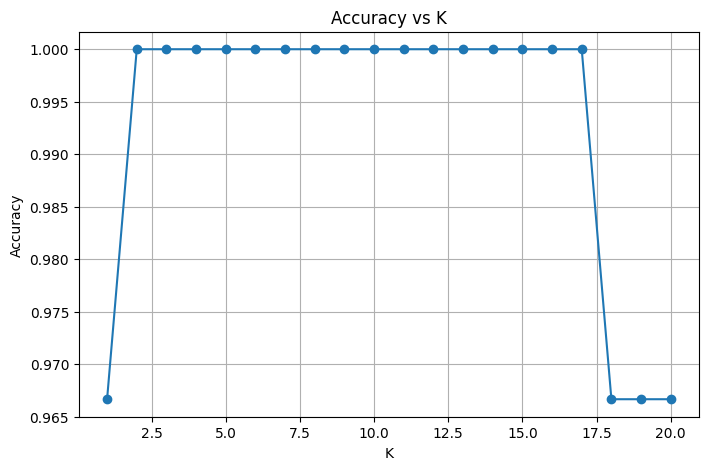

In [16]:
plt.figure(figsize=(8,5))

plt.plot(K,accuracies,marker='o')

plt.xlabel("K")

plt.ylabel("Accuracy")

plt.title("Accuracy vs K")

plt.grid(True)

plt.show()

## Task 6 Cross Validation

In [17]:
cv_scores=[]

K=range(1,21)

for k in K:

    model=KNeighborsClassifier(n_neighbors=k)

    scores=cross_val_score(
        model,
        X_scaled,
        y,
        cv=5
    )

    cv_scores.append(scores.mean())

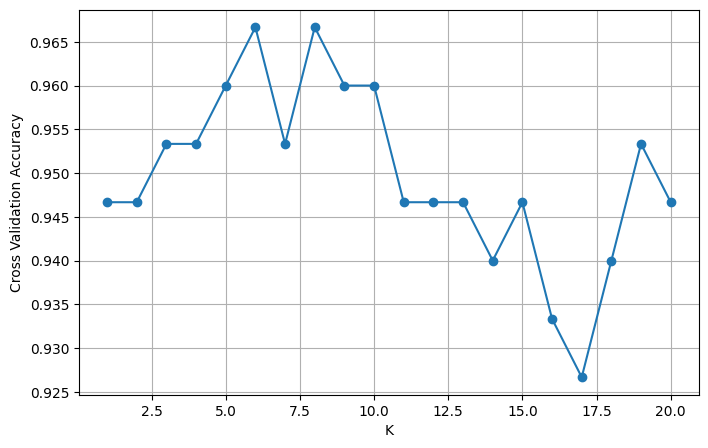

In [18]:
plt.figure(figsize=(8,5))

plt.plot(K,cv_scores,marker='o')

plt.xlabel("K")

plt.ylabel("Cross Validation Accuracy")

plt.grid(True)

plt.show()

### Best k

In [19]:
best_k=np.argmax(cv_scores)+1

print("Best K =",best_k)

Best K = 6


## Task 7 Decision Boundary
### Choose only two features.

In [20]:
X = iris.data[:,[2,3]]

y = iris.target

### scale


In [21]:
scaler=StandardScaler()

X=scaler.fit_transform(X)

### Train

In [22]:
model=KNeighborsClassifier(n_neighbors=3)

model.fit(X,y)

,n_neighbors,3
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


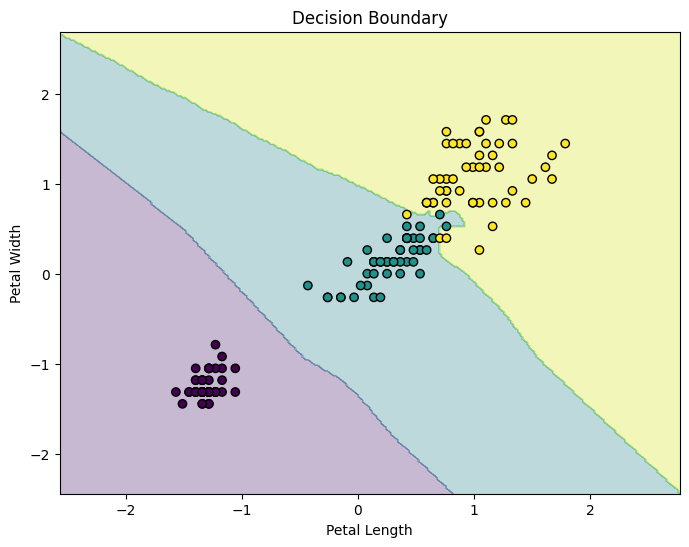

In [23]:
from matplotlib.colors import ListedColormap

x_min,x_max=X[:,0].min()-1,X[:,0].max()+1
y_min,y_max=X[:,1].min()-1,X[:,1].max()+1

xx,yy=np.meshgrid(
    np.arange(x_min,x_max,0.02),
    np.arange(y_min,y_max,0.02)
)

Z=model.predict(
    np.c_[xx.ravel(),yy.ravel()]
)

Z=Z.reshape(xx.shape)

plt.figure(figsize=(8,6))

plt.contourf(xx,yy,Z,alpha=0.3)

plt.scatter(
    X[:,0],
    X[:,1],
    c=y,
    edgecolor='k'
)

plt.xlabel("Petal Length")

plt.ylabel("Petal Width")

plt.title("Decision Boundary")

plt.show()

# Comprehensive Lab Analysis: K-Nearest Neighbors (KNN)

## 1. Final Inference & Implementation Comparison

### Manual vs. Scikit-learn
* **Manual Implementation:** Building KNN from scratch provides invaluable insights into the underlying mechanics of the algorithm. It illustrates exactly how the algorithm computes distances in a multi-dimensional feature space and demonstrates how class labels are predicted via a majority vote.
* **Scikit-Learn Implementation:** The production-ready `KNeighborsClassifier` from Scikit-learn is highly optimized, significantly faster (utilizing advanced data structures like KD-Trees or Ball Trees), and easier to deploy. While the manual and library implementations produce identical results on standard data, Scikit-learn is the clear choice for scalable, real-world applications.

---

## 2. Parameter Analysis & Tuning

### Impact of $K$ Selection
The choice of the hyperparameter $K$ (number of neighbors) directly regulates the model's complexity:
* **Small $K$ Values (e.g., $K=1$):** Create complex, highly irregular decision boundaries. The model captures local noise in the training set, making it highly prone to **overfitting**.
* **Large $K$ Values:** Produce smoother, more generalized boundaries. However, if $K$ is set too high (e.g., approaching the total number of data points), the model will begin to **underfit**, simply predicting the majority class of the entire dataset regardless of the input.
* **Optimal $K$:** Striking the right balance minimizes both bias and variance, leading to the best generalization on unseen data.

### Influence of Distance Metrics
The choice of distance metric alters how "closeness" is defined in the feature space:
* **Euclidean Distance ($L_2$ norm):** Generally performs best on continuous, standardized datasets like the Iris dataset because it measures the true straight-line distance between points.
* **Manhattan Distance ($L_1$ norm):** Calculates distance along a grid-like, axis-aligned path. It may select a slightly different set of nearest neighbors compared to Euclidean distance, proving highly useful in high-dimensional spaces or when features are not strongly continuous.
* **Minkowski Distance:** A generalized metric framework regulated by the parameter $p$. When the default $p=2$ is applied, it behaves exactly like Euclidean distance; when $p=1$, it simplifies to Manhattan distance.

---

## 3. Preprocessing & Validation Strategy

### Importance of Feature Scaling
Because KNN is a **distance-based algorithm**, it is profoundly sensitive to the scale of the input features:
* **The Problem:** If one feature has a numeric range spanning thousands (e.g., income) while another spans decimals (e.g., pH level), the larger feature will completely dominate the distance calculations.
* **The Solution:** Applying **Standardization** (scaling features to have a mean of 0 and a variance of 1) ensures that every attribute contributes equally to neighbor selection and prevents structural bias.

### Role of Cross-Validation
Relying on a single train-test split can introduce selection bias, where a specific hyperparameter performs well purely by chance. 
* **Reliability:** Cross-validation provides a robust estimate of model performance